# Gurobi Monotonic Approximation of Prices
version 1.1

In [101]:
# Let's start off by loading in the packages

# Let's load in the necessary packages
import pandas as pd
import datetime
import os
import timeit
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB
import numpy as np

### Loading in some data

In [102]:
# Loading in the data first.
# Let's load in the data here, and for now, let's make it just for four hours.

file_name = os.fsdecode("marco_data.csv")
workbook = pd.read_csv(file_name)
workbook = workbook.filter(items=["date", "he", "size","flexible","price"]) # Gets the columns that we need


workbook = workbook.query('date=="2024-04-10"') # Remove this to take out the filter for the day.

# Getting the columns we need.
merit_data = workbook.filter(items=["date", "he", "size","flexible","price","mkt_price","ail","datetime"]) # Gets the columns that we need
# I added "datetime" above so that it will be easier to filter out the merit data when looping through.

# merit_data

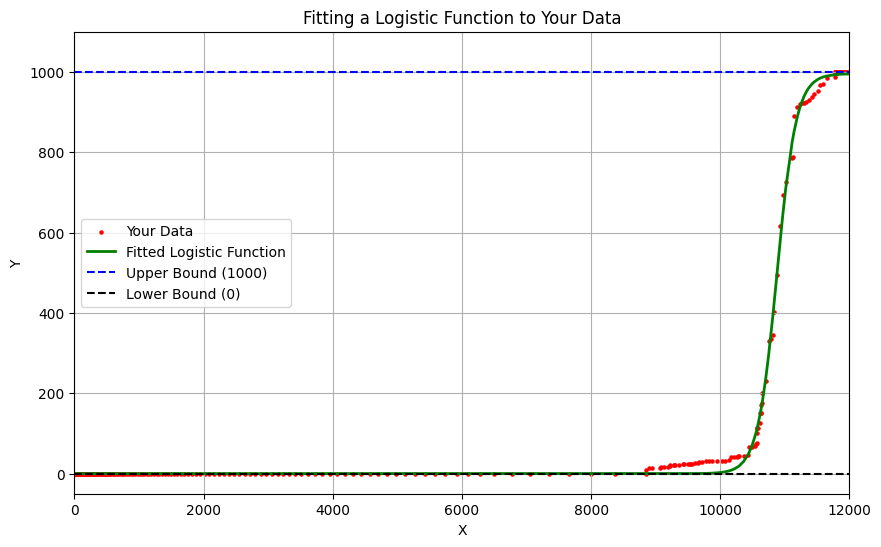

Fitted parameters:
L (max value): 995.487250586587
k (steepness): 0.006707311936583035
x0 (midpoint): 10878.240387446122


In [103]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Generate synthetic data for demonstration
# Replace this with your actual data
x = bids['merit']

# Generate y values according to your specifications
# Start at 0 for x in [0, 5000] and reach 1000 for x in [10000, 12000]
y = bids['price']
# Define the logistic function for fitting
def logistic_function(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))

# Initial guesses for parameters: L, k, x0
initial_guesses = [1000, 0.0001, 7500]  # Adjusted values for wider x range

# Fit the logistic function to your data
popt, pcov = curve_fit(logistic_function, x, y, p0=initial_guesses)

# Extract fitted parameters
L_fit, k_fit, x0_fit = popt

# Generate fitted values
y_fitted = logistic_function(x, *popt)

# Plot your data and the fitted logistic function
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Your Data', color='red', s=5)
plt.plot(x, y_fitted, label='Fitted Logistic Function', color='green', linewidth=2)
plt.axhline(y=1000, color='blue', linestyle='--', label='Upper Bound (1000)')
plt.axhline(y=0, color='black', linestyle='--', label='Lower Bound (0)')
plt.xlim(0, 12000)  # Set x limits according to your domain
plt.ylim(-50, 1100)  # Adjust y-limits as necessary
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Fitting a Logistic Function to Your Data')
plt.legend()
plt.grid()
plt.show()

# Print the fitted parameters
print("Fitted parameters:")
print(f"L (max value): {L_fit}")
print(f"k (steepness): {k_fit}")
print(f"x0 (midpoint): {x0_fit}")

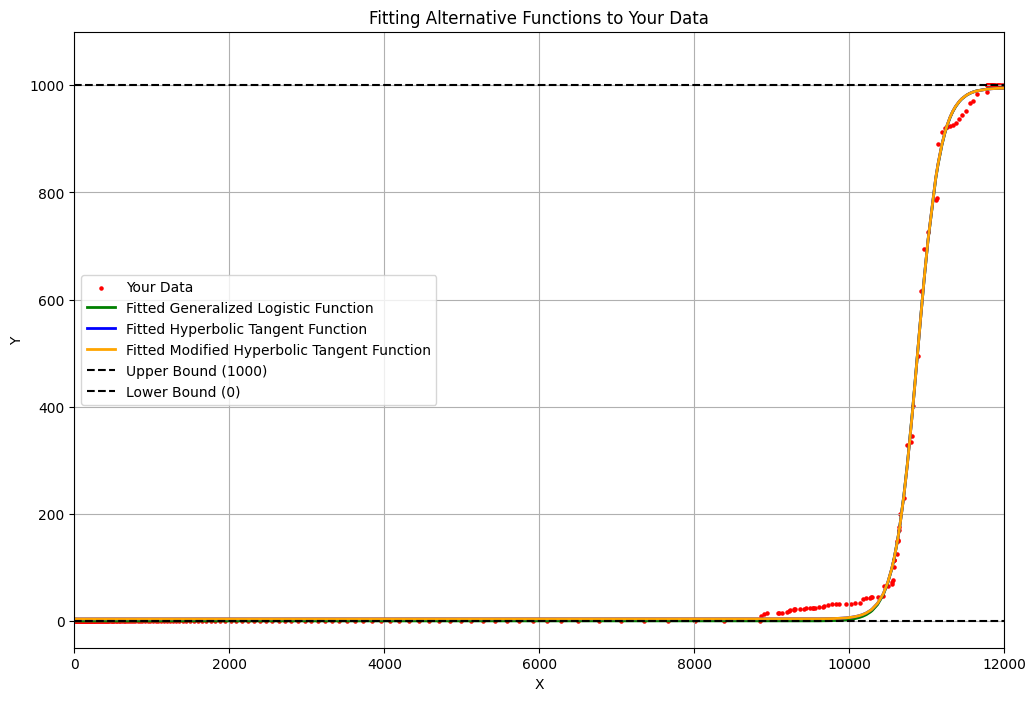

Fitted parameters for Generalized Logistic Function:
L (max value): 995.487460124823
k (steepness): 0.0005890514721444125
x0 (midpoint): 10878.240739994553
b (curvature): 11.386583136901752

Fitted parameters for Hyperbolic Tangent Function:
A (amplitude): 495.6468302663843
B (steepness): 0.0033882124143353822
C (midpoint): 10879.642942045824
D (baseline): 499.47053242571656


In [106]:
# Define the generalized logistic function for fitting
def generalized_logistic(x, L, k, x0, b):
    return L / (1 + np.exp(-k * (x - x0))**b)

# Define the hyperbolic tangent function for fitting
def tanh_function(x, A, B, C, D):
    return A * np.tanh(B * (x - C)) + D

# Initial guesses for generalized logistic parameters
initial_guesses_logistic = [1000, 0.0001, 7500, 1]  # L, k, x0, b

# Fit the generalized logistic function to your data
popt_logistic, pcov_logistic = curve_fit(generalized_logistic, x, y, p0=initial_guesses_logistic)

# Fit the hyperbolic tangent function to your data
initial_guesses_tanh = [1000, 0.00001, 7500, 0]  # A, B, C, D
popt_tanh, pcov_tanh = curve_fit(tanh_function, x, y, p0=initial_guesses_tanh)

# Generate fitted values
y_fitted_logistic = generalized_logistic(x, *popt_logistic)
y_fitted_tanh = tanh_function(x, *popt_tanh)


def modified_tanh(x, A, k, x0, b):
    return A * np.tanh(k * (x - x0)) + b




# Set initial parameter guesses
initial_guesses = [1000, 0.001, 5000, 0]

# Fit the modified hyperbolic tangent function to your data
popt_mtanh, pcov_mtanh = curve_fit(modified_tanh, x, y, p0=initial_guesses)

# Extract fitted parameters
A_fit, k_fit, x0_fit, b_fit = popt_mtanh

# Generate fitted values
y_fitted_mtanh = modified_tanh(x, A_fit, k_fit, x0_fit, b_fit)

# Plot your data and the fitted functions
plt.figure(figsize=(12, 8))
plt.scatter(x, y, label='Your Data', color='red', s=5)
plt.plot(x, y_fitted_logistic, label='Fitted Generalized Logistic Function', color='green', linewidth=2)
plt.plot(x, y_fitted_tanh, label='Fitted Hyperbolic Tangent Function', color='blue', linewidth=2)
plt.plot(x, y_fitted_mtanh, label='Fitted Modified Hyperbolic Tangent Function', color='orange', linewidth=2)
plt.axhline(y=1000, color='black', linestyle='--', label='Upper Bound (1000)')
plt.axhline(y=0, color='black', linestyle='--', label='Lower Bound (0)')
plt.xlim(0, 12000)  # Set x limits according to your domain
plt.ylim(-50, 1100)  # Adjust y-limits as necessary
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Fitting Alternative Functions to Your Data')
plt.legend()
plt.grid()
plt.show()

# Print the fitted parameters
print("Fitted parameters for Generalized Logistic Function:")
print(f"L (max value): {popt_logistic[0]}")
print(f"k (steepness): {popt_logistic[1]}")
print(f"x0 (midpoint): {popt_logistic[2]}")
print(f"b (curvature): {popt_logistic[3]}")

print("\nFitted parameters for Hyperbolic Tangent Function:")
print(f"A (amplitude): {popt_tanh[0]}")
print(f"B (steepness): {popt_tanh[1]}")
print(f"C (midpoint): {popt_tanh[2]}")
print(f"D (baseline): {popt_tanh[3]}")